<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Normalization Techniques**


Estimated time needed: **30** minutes


In this lab, you will focus on data normalization. This includes identifying compensation-related columns, applying normalization techniques, and visualizing the data distributions.


## Objectives


In this lab, you will perform the following:


- Identify duplicate rows and remove them.

- Check and handle missing values in key columns.

- Identify and normalize compensation-related columns.

- Visualize the effect of normalization techniques on data distributions.


-----


## Hands on Lab


#### Step 1: Install and Import Libraries


In [1]:
!pip install pandas

In [2]:
!pip install matplotlib

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Step 2: Load the Dataset into a DataFrame


We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.


The functions below will download the dataset into your browser:


In [4]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)

# Display the first few rows to check if data is loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

In [5]:
#df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")

### Section 1: Handling Duplicates
##### Task 1: Identify and remove duplicate rows.


In [6]:
## Write your code here

dup=df.duplicated()

print('number od duplicated rows', dup.sum())
print('shape before_removal',df.shape)

df=df.drop_duplicates()
print('shape after_removal',df.shape)

df[dup].head(10) #shows duplicated rows

number od duplicated rows 0
shape before_removal (65437, 114)
shape after_removal (65437, 114)


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat


### Section 2: Handling Missing Values
##### Task 2: Identify missing values in `CodingActivities`.


In [7]:
## Write your code here

emptyCodingActivities=df['CodingActivities'].isnull()
print('number of empty rows in CodingActivities:', emptyCodingActivities.sum())

df[emptyCodingActivities].head(10)

number of empty rows in CodingActivities: 10971


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN
5,6,I code primarily as a hobby,Under 18 years old,"Student, full-time",NaN,Apples,NaN,Primary/elementary school,"School (i.e., University, College, etc);Online...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
7,8,I am learning to code,18-24 years old,"Student, full-time;Not employed, but looking f...",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Video-based Online Cou...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Difficult,NaN,NaN
13,14,"I used to be a developer by profession, but no...",35-44 years old,"Not employed, and not looking for work",NaN,Apples,NaN,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Colleague;Other online resources (e.g., videos...",Technical documentation;Blogs;Stack Overflow;I...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Neither easy nor difficult,NaN,NaN
16,17,I code primarily as a hobby,Under 18 years old,"Student, full-time",NaN,Apples,NaN,Primary/elementary school,Books / Physical media;Other online resources ...,Technical documentation;Written Tutorials;Stac...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
30,31,I am a developer by profession,Prefer not to say,"Student, full-time",NaN,Apples,NaN,Something else,"Books / Physical media;School (i.e., Universit...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Neither easy nor difficult,NaN,NaN
34,35,I code primarily as a hobby,Under 18 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...",On the job training;Other online resources (e....,Technical documentation;Stack Overflow;Interac...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN
39,40,I am a developer by profession,Under 18 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...",Books / Physical media;Other online resources ...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
50,51,"I am not primarily a developer, but I write co...",18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Stack Overflow;S...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN


##### Task 3: Impute missing values in CodingActivities with forward-fill.


In [8]:
## Write your code here

df['CodingActivities']=df['CodingActivities'].ffill()

emptyCodingActivities=df['CodingActivities'].isnull()
print('number of empty rows in CodingActivities:', emptyCodingActivities.sum())

df['CodingActivities'].head(20)

number of empty rows in CodingActivities: 0


0                                                 Hobby
1     Hobby;Contribute to open-source projects;Other...
2     Hobby;Contribute to open-source projects;Other...
3     Hobby;Contribute to open-source projects;Other...
4     Hobby;Contribute to open-source projects;Other...
5     Hobby;Contribute to open-source projects;Other...
6                          I don’t code outside of work
7                          I don’t code outside of work
8                                                 Hobby
9                              Bootstrapping a business
10             Hobby;Contribute to open-source projects
11                        Hobby;School or academic work
12    Hobby;Contribute to open-source projects;Profe...
13    Hobby;Contribute to open-source projects;Profe...
14    Hobby;Professional development or self-paced l...
15                                                Hobby
16                                                Hobby
17    Hobby;Professional development or self-pac

**Note**:  Before normalizing ConvertedCompYearly, ensure that any missing values (NaN) in this column are handled appropriately. You can choose to either drop the rows containing NaN or replace the missing values with a suitable statistic (e.g., median or mean).


In [9]:
df['ConvertedCompYearly'].isnull().sum()

np.int64(42002)

Around 35% of rows in this column contains data so imputing the remaining 65% with mean or median will lead to extreme data centralization

In [10]:
print('df shape before droping', df.shape)
df=df.dropna(subset='ConvertedCompYearly', axis=0)
print('df shape after droping', df.shape)

df shape before droping (65437, 114)
df shape after droping (23435, 114)


### Section 3: Normalizing Compensation Data
##### Task 4: Identify compensation-related columns, such as ConvertedCompYearly.
Normalization is commonly applied to compensation data to bring values within a comparable range. Here, you’ll identify ConvertedCompYearly or similar columns, which contain compensation information. This column will be used in the subsequent tasks for normalization.


In [11]:
## Write your code here

df['ConvertedCompYearly'].describe()

count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64

Based on Input_Missing_Values, removing outliers to reduce noise and improve visualization.

In [12]:
comp=df['ConvertedCompYearly']

print('df shape before drop',df.shape)

Q1converted=np.quantile(comp, 0.25)
Q3converted=np.quantile(comp, 0.75)
converted_IQR=Q3converted-Q1converted

converted_max_value=Q3converted+4*converted_IQR

comp_to_drop=comp[comp>converted_max_value]

df=df.drop(comp_to_drop.index, axis=0)

print('df shape after drop',df.shape)

df shape before drop (23435, 114)
df shape after drop (23241, 114)


##### Task 5: Normalize ConvertedCompYearly using Min-Max Scaling.
Min-Max Scaling brings all values in a column to a 0-1 range, making it useful for comparing data across different scales. Here, you will apply Min-Max normalization to the ConvertedCompYearly column, creating a new column ConvertedCompYearly_MinMax with normalized values.


In [13]:
## Write your code here

comp=df['ConvertedCompYearly']
c_min=comp.min()
c_max=comp.max()

df['ConvertedCompYearly_MinMax']=(comp-c_min)/(c_max-c_min)

##### Task 6: Apply Z-score Normalization to `ConvertedCompYearly`.

Z-score normalization standardizes values by converting them to a distribution with a mean of 0 and a standard deviation of 1. This method is helpful for datasets with a Gaussian (normal) distribution. Here, you’ll calculate Z-scores for the ConvertedCompYearly column, saving the results in a new column ConvertedCompYearly_Zscore.


In [14]:
## Write your code here

c_mean=comp.mean()
c_std=comp.std()

df['ConvertedCompYearly_Zscore']=(comp-c_mean)/c_std

### Section 4: Visualization of Normalized Data
##### Task 7: Visualize the distribution of `ConvertedCompYearly`, `ConvertedCompYearly_Normalized`, and `ConvertedCompYearly_Zscore`

Visualization helps you understand how normalization changes the data distribution. In this task, create histograms for the original ConvertedCompYearly, as well as its normalized versions (ConvertedCompYearly_MinMax and ConvertedCompYearly_Zscore). This will help you compare how each normalization technique affects the data range and distribution.


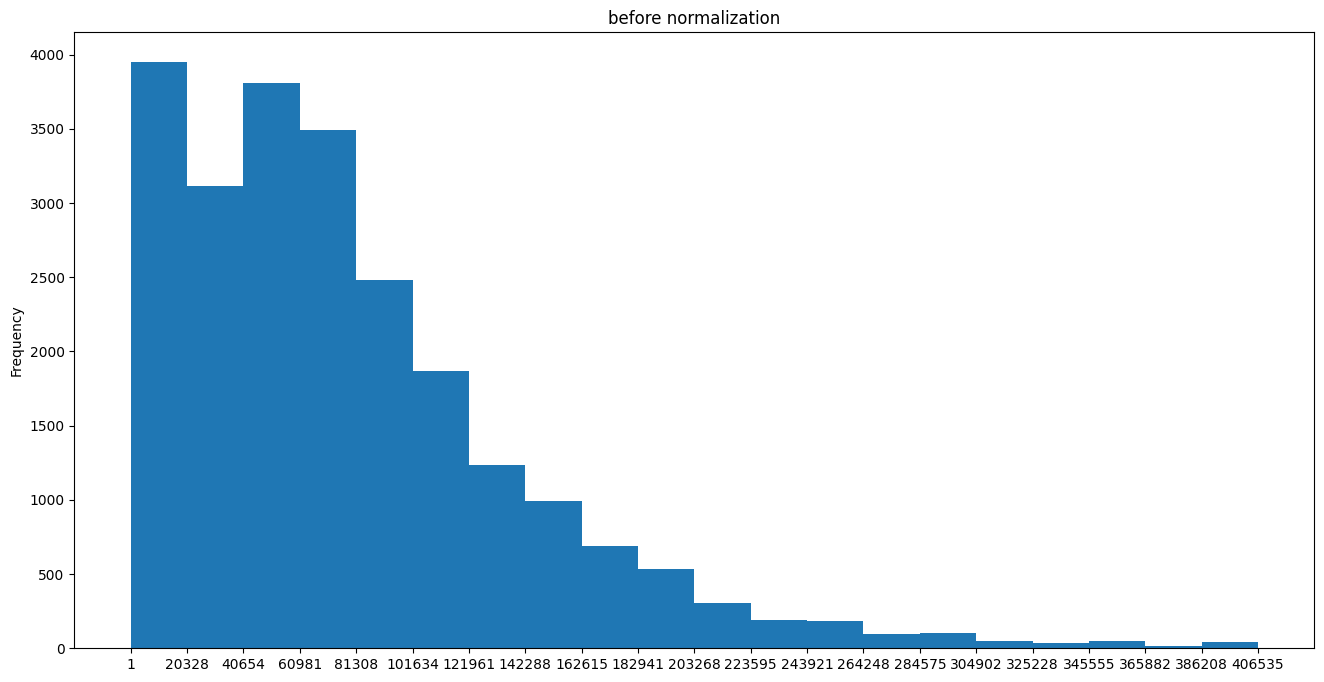

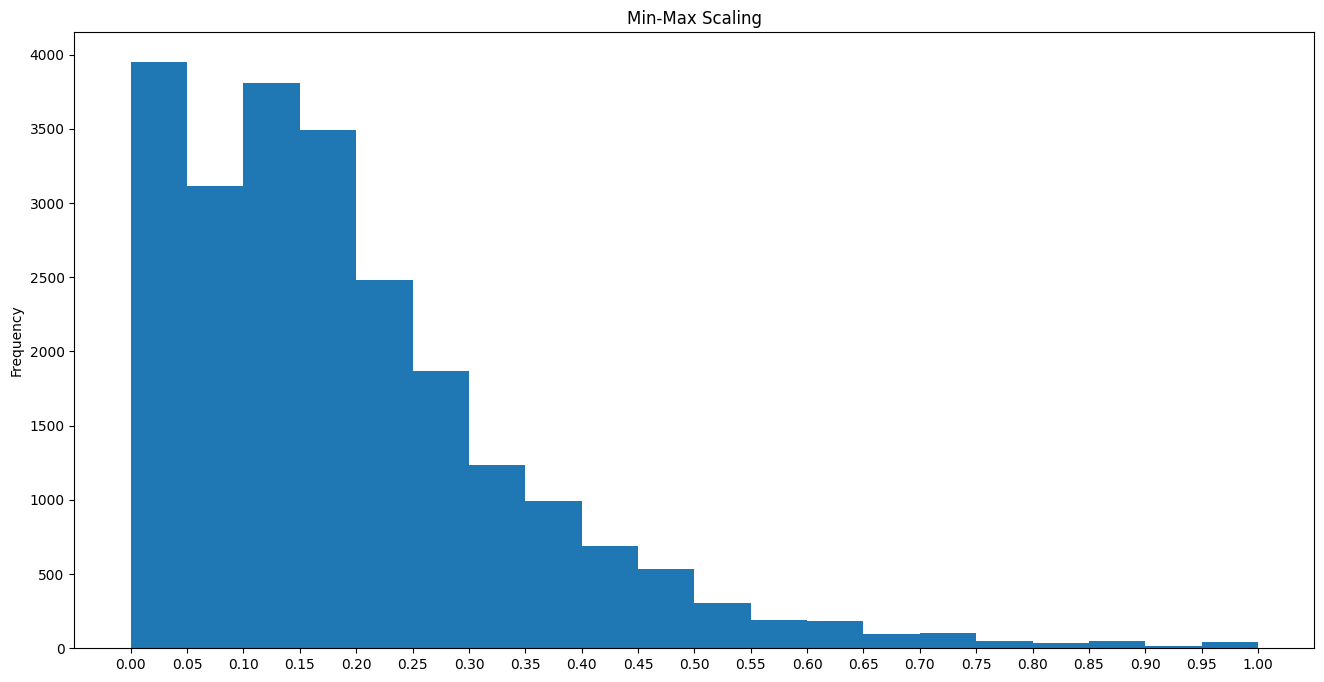

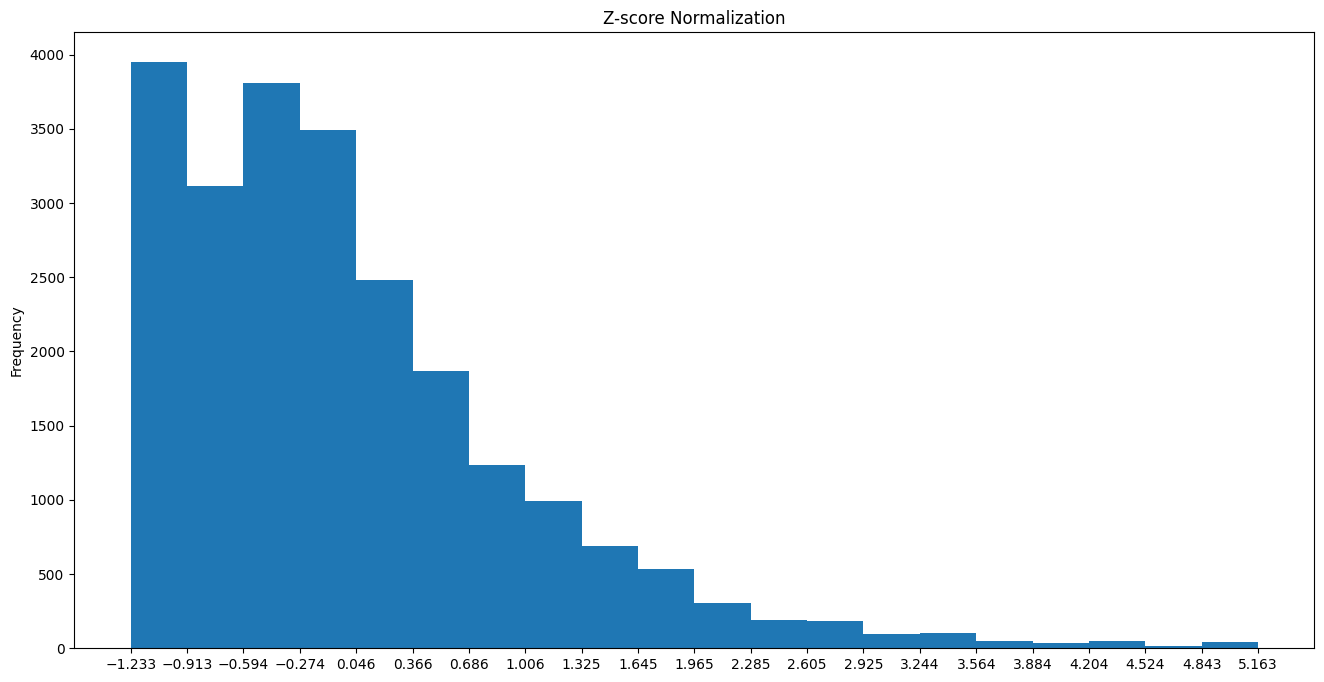

In [15]:
## Write your code here

entries_in_bin, bin_range=np.histogram(df['ConvertedCompYearly'],20)
entries_in_bin_nor, bin_range_nor=np.histogram(df['ConvertedCompYearly_MinMax'],20)
entries_in_bin_z, bin_range_z=np.histogram(df['ConvertedCompYearly_Zscore'],20)

df['ConvertedCompYearly'].plot(kind='hist', figsize=(16,8), xticks=bin_range, bins=20)
plt.title('before normalization')
plt.show()

df['ConvertedCompYearly_MinMax'].plot(kind='hist', figsize=(16,8), xticks=bin_range_nor, bins=20)
plt.title('Min-Max Scaling')
plt.show()

df['ConvertedCompYearly_Zscore'].plot(kind='hist', figsize=(16,8), xticks=bin_range_z, bins=20)
plt.title('Z-score Normalization')
plt.show()

### Summary


In this lab, you practiced essential normalization techniques, including:

- Identifying and handling duplicate rows.

- Checking for and imputing missing values.

- Applying Min-Max scaling and Z-score normalization to compensation data.

- Visualizing the impact of normalization on data distribution.


Copyright © IBM Corporation. All rights reserved.
